In [2]:
%load_ext autoreload
    
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
import sys

from acacia_s2s_toolkit.hindcast_skill import *

from acacia_s2s_toolkit.bias_correction import biascorrection
from acacia_s2s_toolkit.postprocess import get_example_data
from acacia_s2s_toolkit.postprocess import read_netcdf,\
                                            deaccumulate,\
                                            align_grid,\
                                            set_verbose,\
                                            align_time,\
                                            organize_by_leadtime,\
                                            _log,\
                                            aggregate,\
                                            leadtime_to_time,\
                                            organize_by_validtime,\
                                            add_enslag

import warnings

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
data_dir="./data"

In [4]:
# defining what you want to process - i.e. forecast date, domain and observed dataset

# nominal forecast date is defined here. 
# This notebook uses example data for this date only
# example data are downloaded by a function get_example_data() called above

#"2026-09-15" - rc_enslags=[-1,1], fc_time=True
#"2026-09-10" - rc_enslags=[-1,1], fc_time=False
#"2026-09-12" - fc_enslags=[-1,-3], rc_enslags=[-1,1], fc_time=False
#"2026-09-06" rf_enslags=[-1], fc_enslags=[-1], fc_time=False


nominal_date="2026-09-10"
#target domain
target_domain="madagascar"
#forecast variable
fcst_var="tp"
#foreast model
fcst_model="ECMWF"

#this is file with observational data. It is gridded and covers the period of Jan 1981-March 2026
obs_file=f"{data_dir}/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc"

#we have to provide the name of the variable stored in the obs_file
obs_var="PRCPTOT"

# this is a file with vector data showing the boundaries of the domain - will be used in plotting only
domain_shape_file=f"{data_dir}/madagascar.geojson"

# data will be aggregated into blocks of this size - "5D" is a Pandas expression of temporal base and stands for 5 days
# if you want differently sized blocks - just change it into, say "7D"
#agg_window="5D"

window_size=5

#and this defines how data will be aggreagated over the block - in this case it will be a sum of daily values
agg_method="sum"

# this defines regridding parameters for matching the obs and forecast grids. 
# it assumes obs grid is finer, so fine_to_coarse will give forecast grid, coarse_to_fine will give obs grid
# raise_if_missing will stop processing if the spatial overlap between obs and forecast grids of less than fractional 
# threshold
#grid_alignment_kwargs=dict(
#    direction="fine_to_coarse",
#    method="conservative",
#    raise_if_missing=True,
#    threshold=0.9
#)

grid_alignment_kwargs=dict(
    direction="coarse_to_fine",
    method="bilinear",
    raise_if_missing=True,
    threshold=0.9
)

# this defines time alignment parameter for matching the obs and hindcast time series. 
# raise_if_missing will stop processing if any of the hindcast days are not covered by observations 
time_alignment_kwargs={"raise_if_missing":True}

set_verbose(False)


#deriving secondary parameters
fcst_date=pd.to_datetime(nominal_date)

fcst_date_str=fcst_date.strftime("%Y%m%d")

download_dir="./data"
# forecast data file
fcst_file="{}/{}_{}_{}_{}_fc.nc".format(download_dir,fcst_var,fcst_model, fcst_date_str, target_domain)

# hindcast data file
hcst_file="{}/{}_{}_{}_{}_hc.nc".format(download_dir,fcst_var,fcst_model, fcst_date_str, target_domain)


verbosity is False


In [5]:
#=============================================================
#prelim stuff - reading and organizing data...


#reading forecast data
fcst_raw=read_netcdf(fcst_file, fcst_var)

#reading hindast
hcst_raw=read_netcdf(hcst_file, fcst_var)

# reading observed data
obs_raw=read_netcdf(obs_file, obs_var)


#this is temporary - because files i have do not have enslag coordinate
hcst_raw=add_enslag(hcst_raw, nominal_date)
fcst_raw=add_enslag(fcst_raw, nominal_date)

#accumulated to daily - note that this will drop one time step
print("\ndeaccumulating...")
fcst_day=deaccumulate(fcst_raw)
hcst_day=deaccumulate(hcst_raw)

print(f"nobs raw: {obs_raw.shape}")
print(f"hcst raw: {hcst_raw.shape}")
print(f"hcst deaccumulated: {hcst_day.shape}")

print("\naligning grids...")
#this aligns grids of forecast and observed
obs_align,fcst_align=align_grid(obs_raw, fcst_day, **grid_alignment_kwargs)

#observed overwrites the previous one, but assumption is that forecast and hindcast are on the same grid
obs_align,hcst_align=align_grid(obs_raw, hcst_day, **grid_alignment_kwargs)

print(f"obs aligned: {obs_align.shape}")
print(f"hcst aligned: {hcst_align.shape}")

print("\naligning time...")
#making sure times are aligned. Note that obs_tslice will have member dimension 
# and for each member will have obs data corresponding to hindcast
obs_ts,hcst_ts=align_time(obs_align, hcst_align, add_members=True, **time_alignment_kwargs)
#for consistency:
fcst_ts=fcst_align.copy()

print(f"obs sliced: {obs_ts.shape}")
print(f"hcst sliced: {hcst_ts.shape}")


deaccumulating...
nobs raw: (16467, 58, 36)
hcst raw: (640, 22, 11, 7)
hcst deaccumulated: (620, 22, 11, 7)

aligning grids...
obs aligned: (16467, 58, 36)
hcst aligned: (620, 22, 58, 36)

aligning time...
obs sliced: (620, 22, 58, 36)
hcst sliced: (620, 22, 58, 36)


In [6]:
#=============================================================
#processing pipeline for bias-correction of valid_time aggregate starts here...

print(f"obs: {obs_ts.sizes}")
print(f"hcst: {hcst_ts.sizes}")
print(f"fcst: {fcst_ts.sizes}")

print("\norganizing by valid_time and trimming...")
#move from time format to valid_time format
# with trim=True (default) only the overlap of all members will be kept. with enslags of -1,1 - this cuts off 2 days of overlap
# so the resulting leadtime is 26 now
hcst_vt=organize_by_validtime(hcst_ts, trim=True)
fcst_vt=organize_by_validtime(fcst_ts, trim=True)
obs_vt=organize_by_validtime(obs_ts, trim=True, drop_member=False)


print(f"obs by valid time: {obs_vt.sizes}")
print(f"hcst by valid time: {hcst_vt.sizes}")
print(f"fcst by valid time: {fcst_vt.sizes}")

print("\naggregating...")
obs_agg=aggregate(obs_vt,  window_size, "sum")
hcst_agg=aggregate(hcst_vt, window_size, "sum")
fcst_agg=aggregate(fcst_vt,  window_size, "sum")


print(f"obs aggregated: {obs_agg.sizes}")
print(f"hcst aggregated: {hcst_agg.sizes}")
print(f"fcst aggregated: {fcst_agg.sizes}")

print("\nbias-correcting blocks...")
#here window size=1 and is_aggregated=True
fcst_bc,hcst_bc, obs_bc=biascorrection(fcst_agg, hcst_agg, obs_agg, window_size=1, is_aggregated=True, method="qm-ecdf")

print(f"obs aggregated bc: {obs_bc.sizes}")
print(f"hcst aggregated bc: {hcst_bc.sizes}")
print(f"fcst aggregated bc: {fcst_bc.sizes}")

obs: Frozen({'time': 620, 'member': 22, 'lat': 58, 'lon': 36})
hcst: Frozen({'time': 620, 'member': 22, 'lat': 58, 'lon': 36})
fcst: Frozen({'time': 29, 'member': 101, 'lat': 58, 'lon': 36})

organizing by valid_time and trimming...
obs by valid time: Frozen({'valid_time': 20, 'lead_time': 27, 'member': 22, 'lat': 58, 'lon': 36})
hcst by valid time: Frozen({'valid_time': 20, 'lead_time': 27, 'member': 22, 'lat': 58, 'lon': 36})
fcst by valid time: Frozen({'valid_time': 1, 'lead_time': 29, 'member': 101, 'lat': 58, 'lon': 36})

aggregating...
resample_agg: dropping last 2 step(s) of 'lead_time' (27 not divisible by window_size=5); keeping 25 steps.
resample_agg: dropping last 2 step(s) of 'lead_time' (27 not divisible by window_size=5); keeping 25 steps.
resample_agg: dropping last 4 step(s) of 'lead_time' (29 not divisible by window_size=5); keeping 25 steps.
obs aggregated: Frozen({'valid_time': 20, 'lead_time': 5, 'member': 22, 'lat': 58, 'lon': 36})
hcst aggregated: Frozen({'valid_t

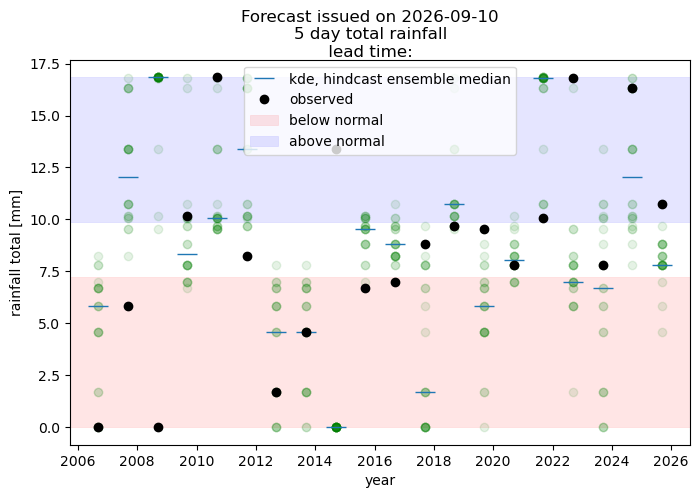

In [7]:
# time series can be visualized for a selected location

# here we will use a location
lat,lon=-20.88,47.62

#we will plot it for a selected lead time
lead_time=0


# we use bias corrected forecast
hcst=hcst_bc.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")

#and observations in the lead-time oriented format
#dropping member as we do not need it anymore
observed=obs_bc.isel(member=0).drop_vars("member")

obs=observed.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")

#now plotting
fig=plt.figure(figsize=(8,5))

pl=fig.add_subplot(1,1,1)

#plotting hincasts - individual members
for m in hcst.member:
    pl.plot(hcst.valid_time,hcst.sel(member=m), "o", color="green", alpha=0.1)

#and hindcast median
pl.plot(hcst.valid_time, hcst.median("member"), "_", ms=15, label="kde, hindcast ensemble median")


#plotting observations
pl.plot(obs.valid_time,obs, "o", color="black", label="observed")

#adding terciles
pl.axhspan(obs.quantile(0.0), obs.quantile(0.33), label="below normal", color="red", alpha=0.1, lw=0.5)
pl.axhspan(obs.quantile(0.66), obs.quantile(1), label="above normal", color="blue", alpha=0.1, lw=0.5)


plt.suptitle("Forecast issued on {}\n{} day total rainfall\n lead time: ".format(nominal_date, window_size, lead_time))

pl.set_xlabel("year")
pl.set_ylabel("rainfall total [mm]")
plt.legend()
plt.show()

In [8]:
# getting deterministic forecast
hcst_det=deterministic_hindcast(hcst_bc,observed, index="relanom")

#getting probabilistic tercile forecast. Each tercile separately...
hcst_prob_above=probabilistic_hindcast(hcst_bc,observed, quant_thresh=0.66, exceed="above")
hcst_prob_below=probabilistic_hindcast(hcst_bc,observed, quant_thresh=0.33, exceed="below")
hcst_prob_normal=probabilistic_hindcast(hcst_bc,observed, quant_thresh=0.33, exceed="above", other_thresh=0.66)


/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


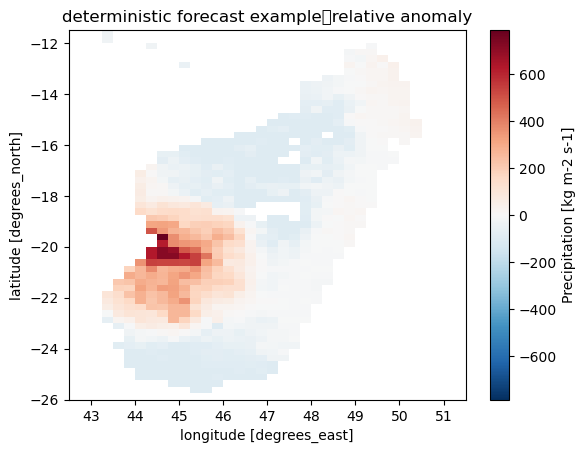

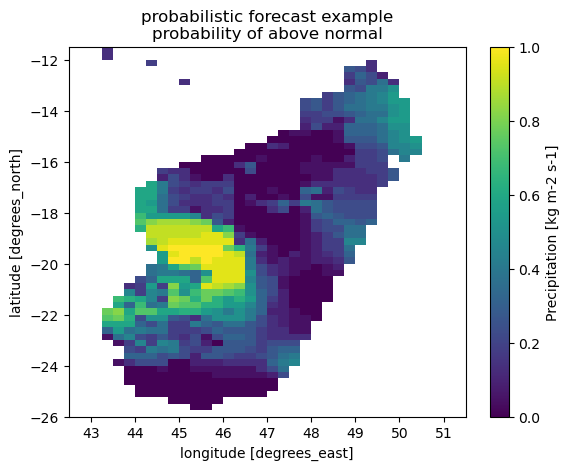

In [9]:
#plotting...
#for a particular init_time and lead time
# there is something wrong here - I'm not sure why the nans in the middle of madagascar. There should not be any nans there. Have to find out what causes it.
hcst_det[-1,0,:].plot()
plt.title("deterministic forecast example\arelative anomaly")
plt.show()

hcst_prob_above[-1,0,:].plot()
plt.title("probabilistic forecast example\nprobability of above normal")
plt.show()


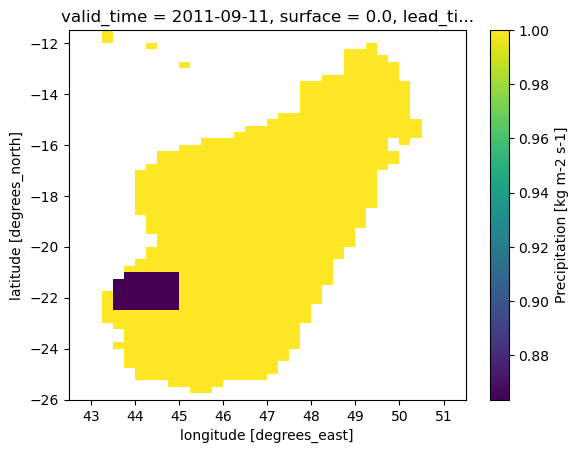

In [10]:
#checking probabilistic hindcast...
#there is something wrong in the process, because map shouls show all 1s. need to find what causes it...
(hcst_prob_above+hcst_prob_below+hcst_prob_normal)[5,1,:].plot()


In [11]:
#hincast deterministic skill
rmse=hindcast_deterministic_skill(hcst_det,observed, score="rmse")

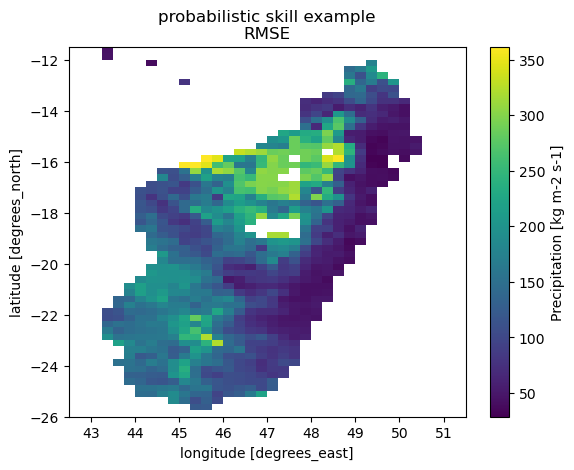

In [12]:
#plotting skill, here we just have lead time
rmse[0,:,:].plot()
plt.title("probabilistic skill example\nRMSE")
plt.show()

In [13]:
#preparation for probabilstic skill
#for heidke skill - have to calculate observed tercile categories first
obs_cat=get_obs_category(observed, quant_thresh=[0.33,0.66])

#and then stitch the three tercile probabilities into one dataset
hcst_prob=xr.concat([hcst_prob_below,hcst_prob_normal,hcst_prob_above], dim=pd.Index(["below", "normal", "above"], name="category"),coords="minimal", compat="override")

# now calculating heidke skill score
hss=hindcast_probabilistic_skill("heidke", hcst_prob=hcst_prob, obs_cat=obs_cat)


/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/work/code/acacia/acacia-s2s-toolkit/src/acacia_s2s_toolkit/hindcast_skill.py:346: RuntimeWarning: invalid value encountered in scalar divide
  HSS = (N_c - N_e) / (N_t - N_e)


Text(0.5, 1.0, 'Heidke Skill Score')

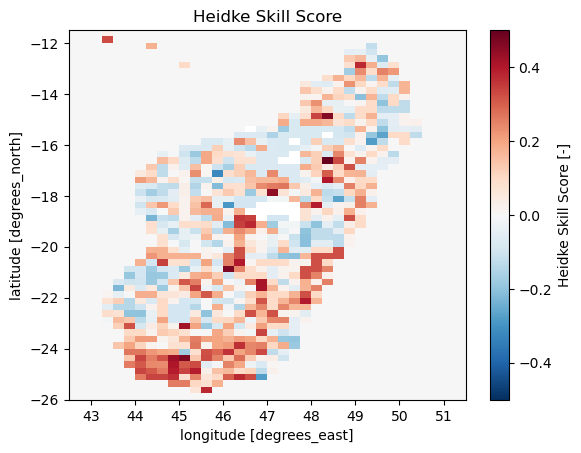

In [16]:
#plotting now
#first fixing some mess. This should happen in the skill function, not here. It will in due time..
hss.attrs["units"]="-"
hss.attrs["long_name"]="Heidke Skill Score"

#plotting for the first lead time
hss[0,:].plot()
plt.title("Heidke Skill Score")